In [1]:
import numpy as np
import xarray

In [2]:
ds = xarray.open_dataset("https://thredds.climate.ifca.es/thredds/dodsC/pti-clima/ncmls/REANALYSIS/ERA5-Land/Iberia/day/ERA5-Land_Iberia_day.ncml").chunk({"time": 100})
ds["t2m"]

<xarray.DataArray 't2m' (time: 26298, latitude: 101, longitude: 161)> Size: 2GB
dask.array<xarray-t2m, shape=(26298, 101, 161), dtype=float32, chunksize=(100, 101, 161), chunktype=numpy.ndarray>
Coordinates:
  * time       (time) datetime64[ns] 210kB 1950-01-01 1950-01-02 ... 2021-12-31
  * latitude   (latitude) float32 404B 44.0 43.9 43.8 43.7 ... 34.2 34.1 34.0
  * longitude  (longitude) float32 644B -10.0 -9.9 -9.8 -9.7 ... 5.7 5.8 5.9 6.0
Attributes:
    long_name:    2 metre temperature
    units:        K
    _ChunkSizes:  [  1 101 161]

In [3]:
%%time

base = ds["t2m"].sel(time=slice("19610101", "19901231")).mean().compute()
t2m = ds["t2m"].mean(["latitude", "longitude"]).compute()

CPU times: user 17.3 s, sys: 8.28 s, total: 25.6 s
Wall time: 1min 39s


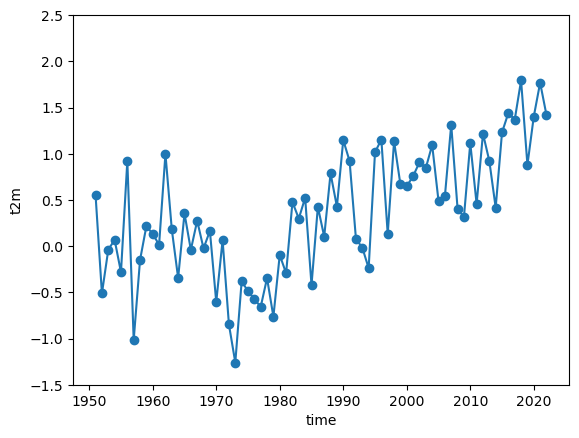

In [4]:
p = (t2m - base).resample({"time": "YE"}).mean().plot.line(ylim=(-1.5, 2.5), marker="o")